In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
datei = "../data/questionaire/Responses.xlsx"

df_during = pd.read_excel(datei, sheet_name="During Experiment")
df_rnan = pd.read_excel(datei, sheet_name="RN AN")
df_post = pd.read_excel(datei, sheet_name="Post Experiment")

print(df_post.columns.tolist())

['Subject', 'Age', 'Date', 'Time', 'List', 'Gender', '1. Worum ging es?', '2. Wie oft gender-inclusive Sprache a) Gesprochen', '2. Wie oft gender-inclusive Sprache b) geschrieben', '3. Wie oft bemerkst du gender-inclusive Sprache? a) gesprochen', '3. Wie oft bemerkst du gender-inclusive Sprache? b) geschrieben', '4. Meinung zu gender-inclusiver Sprache?', '5. Politisches Spektrum', '6. Wann hast du von gender-inclusiver Sprache erfahren?']


In [87]:
anzahl_personen = df_post["Subject"].dropna().nunique()

print("Anzahl Personen:", anzahl_personen)

Anzahl Personen: 14


Age Participants

Personen mit Altersangabe: 14


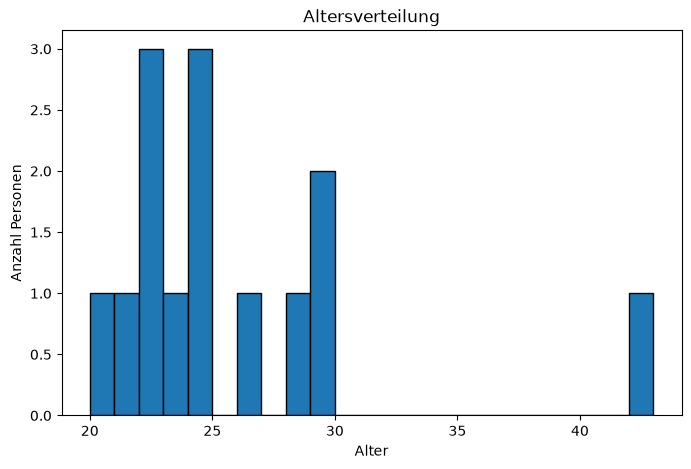

In [88]:
age = pd.to_numeric(df_post["Age"], errors="coerce").dropna()

print("Personen mit Altersangabe:", len(age))

plt.figure(figsize=(8, 5))
plt.hist(age, bins=range(int(age.min()), int(age.max()) + 2), edgecolor="black")

plt.xlabel("Alter")
plt.ylabel("Anzahl Personen")
plt.title("Altersverteilung")

plt.show()

Gender Participant


Geschlecht:


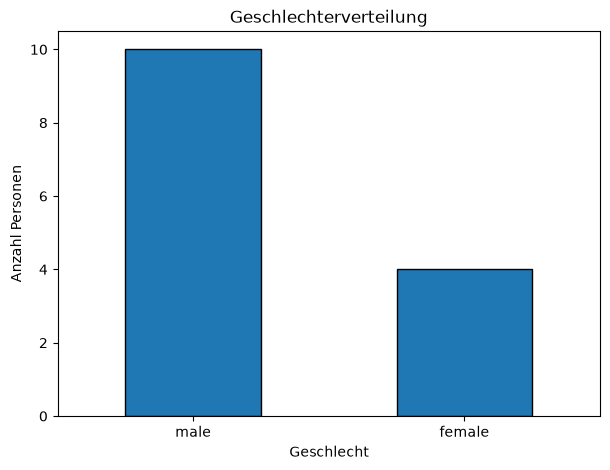

In [89]:
gender = df_post["Gender"].dropna()

print("Geschlecht:")

plt.figure(figsize=(7, 5))
gender.value_counts().plot(kind="bar", edgecolor="black")

plt.xlabel("Geschlecht")
plt.ylabel("Anzahl Personen")
plt.title("Geschlechterverteilung")

plt.xticks(rotation=0)
plt.show()

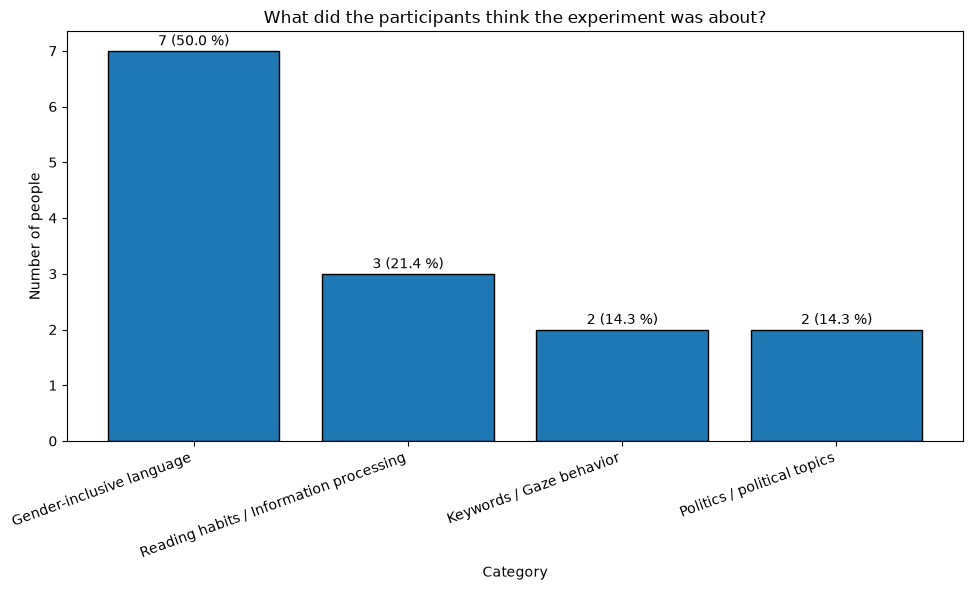

In [99]:
kategorien = [
    "Keywords / Gaze behavior",                       
    "Gender-inclusive language",          
    "Gender-inclusive language",          
    "Politics / political topics",                     
    "Reading habits / Information processing",        
    "Gender-inclusive language",          
    "Reading habits / Information processing",        
    "Gender-inclusive language",          
    "Gender-inclusive language",          
    "Reading habits / Information processing",        
    "Keywords / Gaze behavior",                       
    "Gender-inclusive language",          
    "Politics / political topics",                     
    "Gender-inclusive language"           
]

counts = pd.Series(kategorien).value_counts()

percentages = counts / len(kategorien) * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index, counts.values, edgecolor="black")

plt.xlabel("Category")
plt.ylabel("Number of people")
plt.title("What did the participants think the experiment was about?")
plt.xticks(rotation=20, ha="right")

for bar, count, percentage in zip(bars, counts.values, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{count} ({percentage:.1f} %)",
        ha="center"
    )

plt.tight_layout()
plt.show()

2. Wie oft verwenden die Teilnehmer*innen gender-inclusive Sprache?

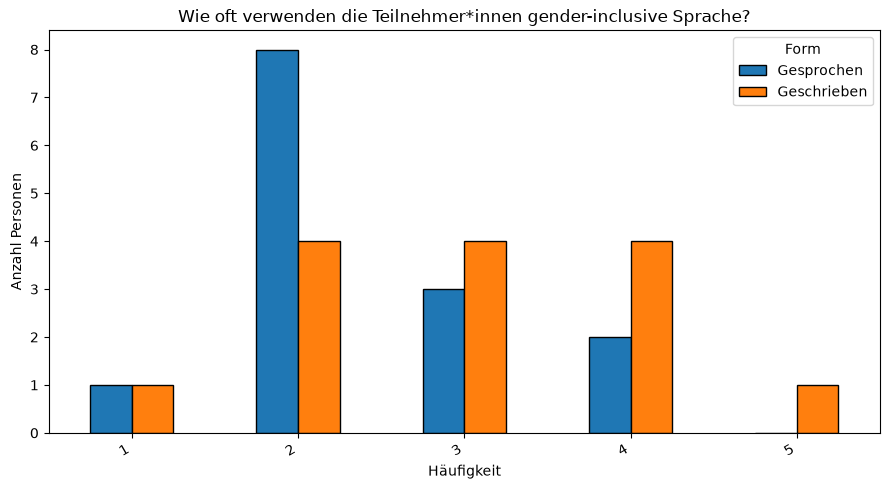

In [91]:
q2_gesprochen = df_post["2. Wie oft gender-inclusive Sprache a) Gesprochen"].dropna().value_counts()
q2_geschrieben = df_post["2. Wie oft gender-inclusive Sprache b) geschrieben"].dropna().value_counts()

vergleich_q2 = pd.DataFrame({
    "Gesprochen": q2_gesprochen,
    "Geschrieben": q2_geschrieben
}).fillna(0)

vergleich_q2.plot(kind="bar", figsize=(9, 5), edgecolor="black")

plt.xlabel("Häufigkeit")
plt.ylabel("Anzahl Personen")
plt.title("Wie oft verwenden die Teilnehmer*innen gender-inclusive Sprache?")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Form")
plt.tight_layout()
plt.show()

Wie oft bemerken Teilnehmer*innen gender-inclusive Sprache?

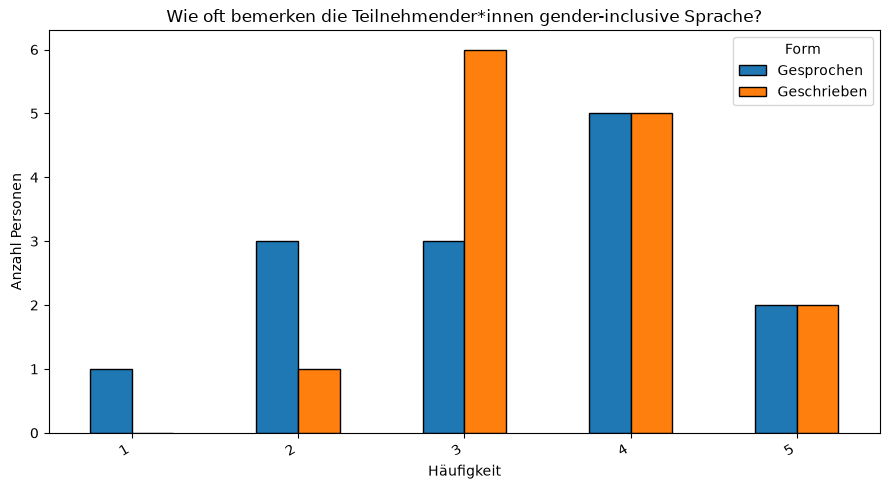

In [92]:
q3_gesprochen = df_post[
    "3. Wie oft bemerkst du gender-inclusive Sprache? a) gesprochen"
].dropna().value_counts()

q3_geschrieben = df_post[
    "3. Wie oft bemerkst du gender-inclusive Sprache? b) geschrieben"
].dropna().value_counts()

vergleich_q3 = pd.DataFrame({
    "Gesprochen": q3_gesprochen,
    "Geschrieben": q3_geschrieben
}).fillna(0)

vergleich_q3.plot(kind="bar", figsize=(9, 5), edgecolor="black")

plt.xlabel("Häufigkeit")
plt.ylabel("Anzahl Personen")
plt.title("Wie oft bemerken die Teilnehmender*innen gender-inclusive Sprache?")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Form")
plt.tight_layout()
plt.show()

C:\Users\sschu\AppData\Local\Temp\ipykernel_2484\2841315973.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


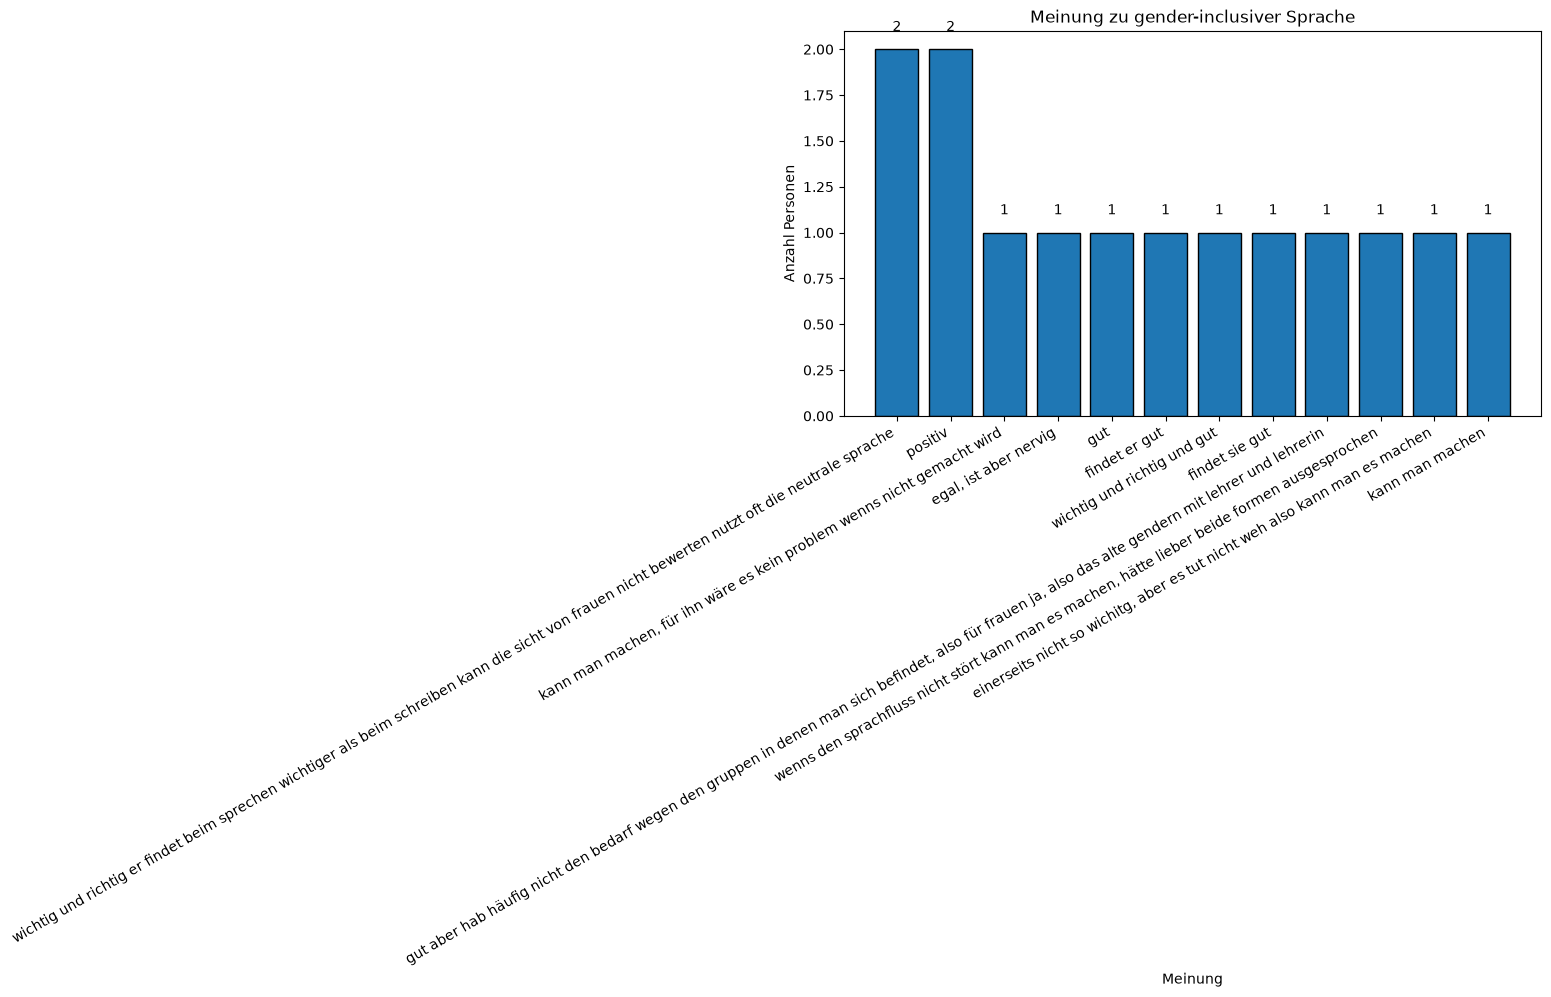

In [93]:
q4 = df_post[
    "4. Meinung zu gender-inclusiver Sprache?"
].dropna().value_counts()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    q4.index.astype(str),
    q4.values,
    edgecolor="black"
)

plt.xlabel("Meinung")
plt.ylabel("Anzahl Personen")
plt.title("Meinung zu gender-inclusiver Sprache")
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, q4.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()

Positiv         9
Neutral         4
eher Negativ    1
Name: count, dtype: int64


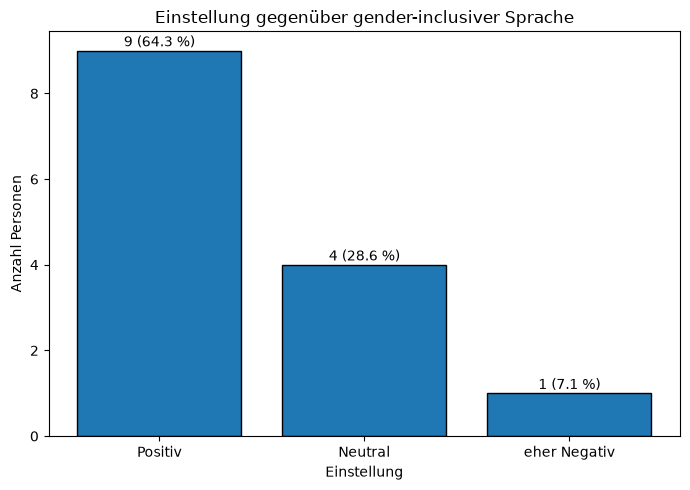

In [94]:
meinungen = [
    "Neutral",  
    "eher Negativ",   
    "Positiv",   
    "Positiv",   
    "Positiv",   
    "Positiv",   
    "Positiv",   
    "Positiv",   
    "Positiv",   
    "Positiv",   
    "Positiv",  
    "Neutral",  
    "Neutral",   
    "Neutral"   
]

counts = pd.Series(meinungen).value_counts()

print(counts)

# Plot
plt.figure(figsize=(7, 5))

bars = plt.bar(
    counts.index,
    counts.values,
    edgecolor="black"
)

plt.xlabel("Einstellung")
plt.ylabel("Anzahl Personen")
plt.title("Einstellung gegenüber gender-inclusiver Sprache")

for bar, count in zip(bars, counts.values):
    percentage = count / len(meinungen) * 100
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{count} ({percentage:.1f} %)",
        ha="center"
    )

plt.tight_layout()
plt.show()

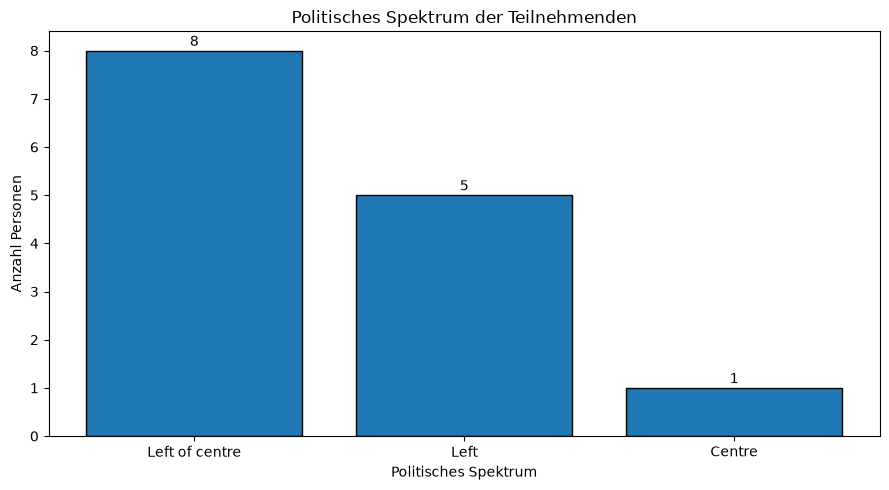

In [95]:
q5 = df_post[
    "5. Politisches Spektrum"
].dropna().value_counts()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    q5.index.astype(str),
    q5.values,
    edgecolor="black"
)

plt.xlabel("Politisches Spektrum")
plt.ylabel("Anzahl Personen")
plt.title("Politisches Spektrum der Teilnehmenden")

for bar, count in zip(bars, q5.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()


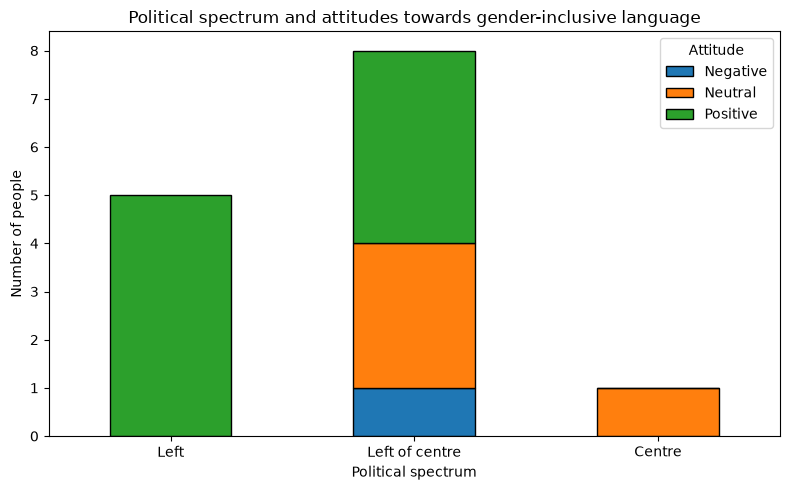

In [96]:
reihenfolge = ["Left", "Left of centre", "Centre"]
meinung = [

    "Neutral",  

    "Negative",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Positive",  

    "Neutral",  

    "Neutral",  

    "Neutral"    

]

df_post["Meinung"] = meinung

df_post["5. Politisches Spektrum"] = pd.Categorical(
    df_post["5. Politisches Spektrum"],
    categories=reihenfolge,
    ordered=True
)

tabelle = pd.crosstab(
    df_post["5. Politisches Spektrum"],
    df_post["Meinung"]
)

# Plot
tabelle.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    edgecolor="black"
)

plt.xlabel("Political spectrum")
plt.ylabel("Number of people")
plt.title("Political spectrum and attitudes towards gender-inclusive language")
plt.xticks(rotation=0)
plt.legend(title="Attitude")
plt.tight_layout()
plt.show()

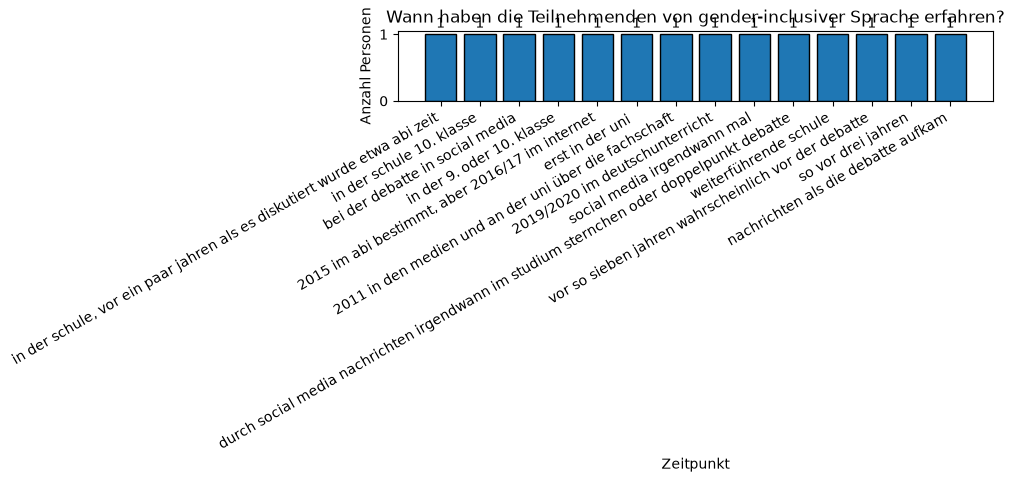

In [97]:
q6 = df_post[
    "6. Wann hast du von gender-inclusiver Sprache erfahren?"
].dropna().value_counts()

plt.figure(figsize=(10, 5))

bars = plt.bar(
    q6.index.astype(str),
    q6.values,
    edgecolor="black"
)

plt.xlabel("Zeitpunkt")
plt.ylabel("Anzahl Personen")
plt.title("Wann haben die Teilnehmenden von gender-inclusiver Sprache erfahren?")
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, q6.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()

Confusion and RN AN 

In [98]:
werte = {
    "Verwirrt": [],
    "Nicht verwirrt": [],
    "RN richtig": [],
    "RN falsch": [],
    "RN falsches Gender": [],
    "AN richtig": [],
    "AN falsch": []
}

for i in range(1, 19):

    confusion = df_rnan[f"{i}. Confusion?"]
    rn = df_rnan[f"{i}. RN right?"]
    an = df_rnan[f"{i}. AN right?"]

    werte["Verwirrt"].append((confusion == "J").sum())
    werte["Nicht verwirrt"].append((confusion == "N").sum())

    werte["RN richtig"].append((rn == "J").sum())
    werte["RN falsch"].append((rn == "N").sum())
    werte["RN falsches Gender"].append((rn == "G").sum())

    werte["AN richtig"].append((an == "J").sum())
    werte["AN falsch"].append((an == "N").sum())

plot_df = pd.DataFrame(werte, index=range(1, 19))

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 7),
    edgecolor="black"
)

plt.xlabel("Frage")
plt.ylabel("Anzahl Personen")
plt.title("Ergebnisse der 18 Fragen")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


KeyError: '1. RN right?'

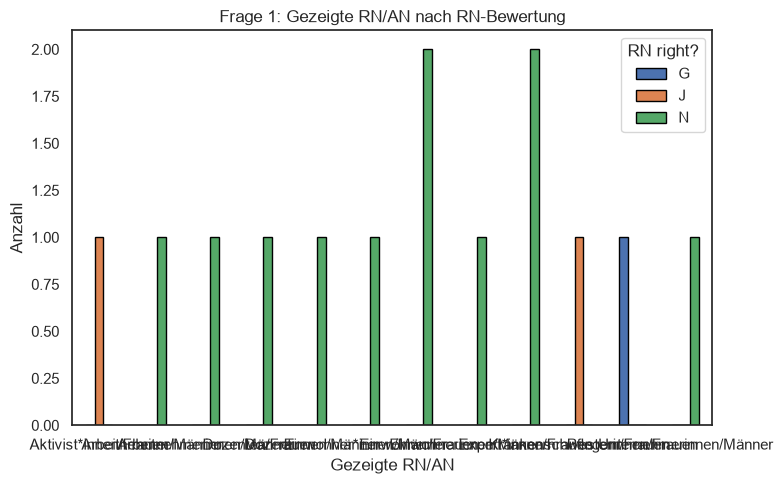

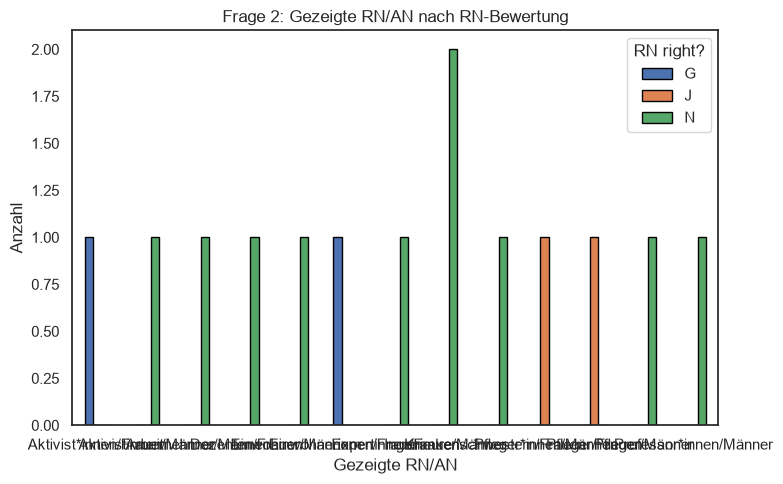

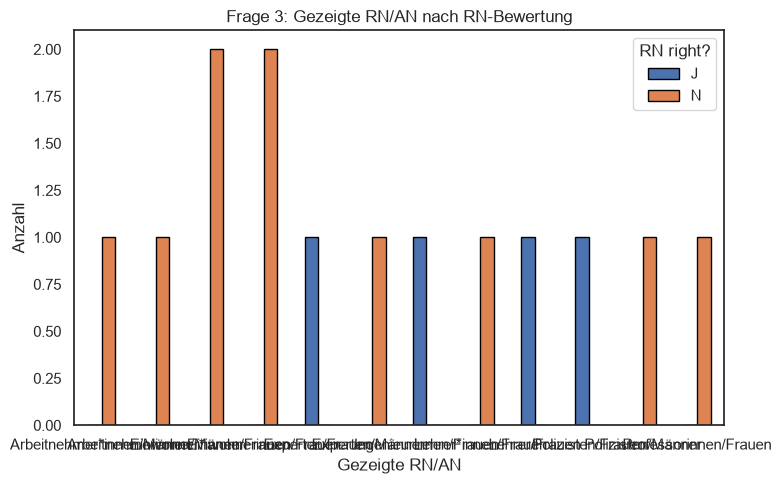

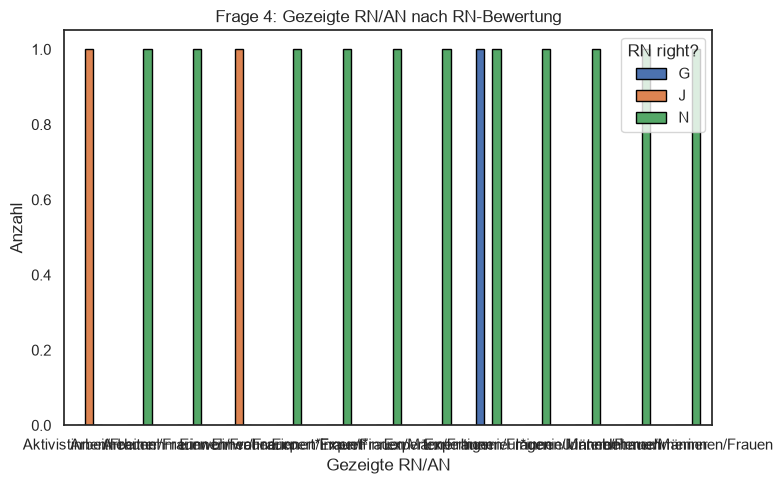

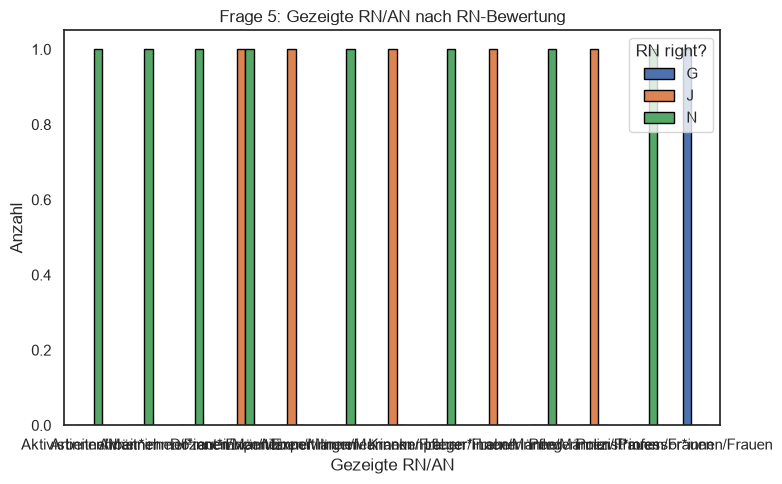

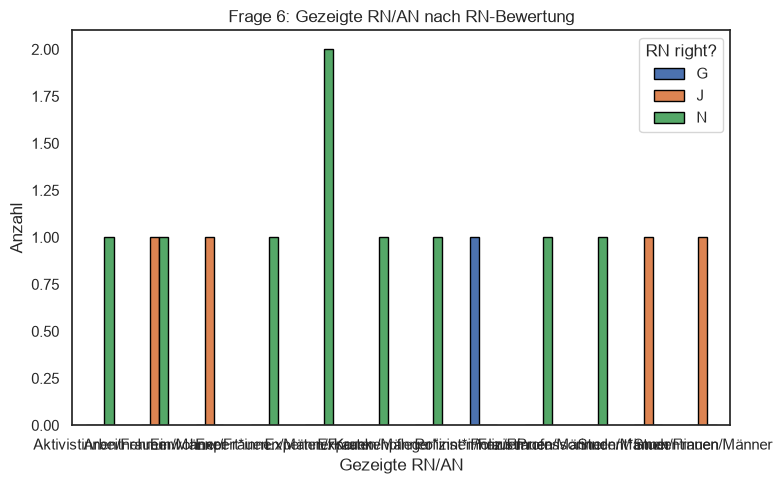

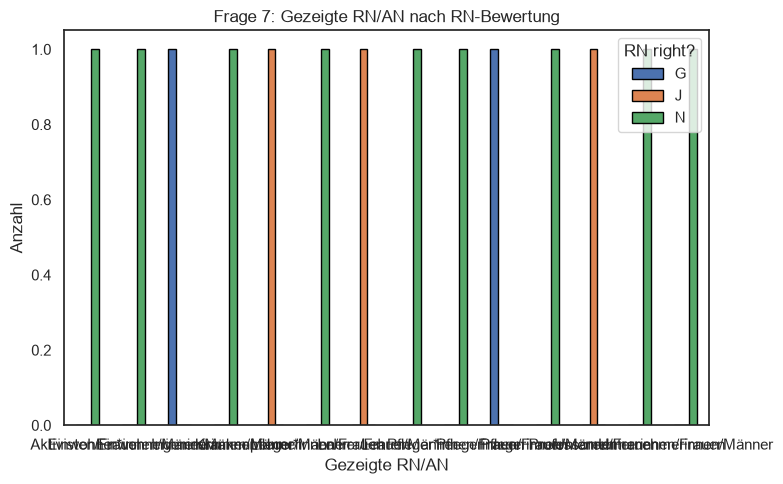

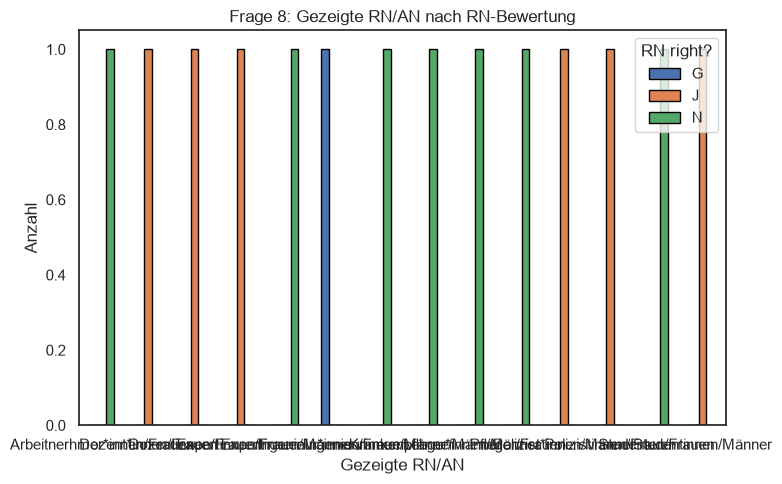

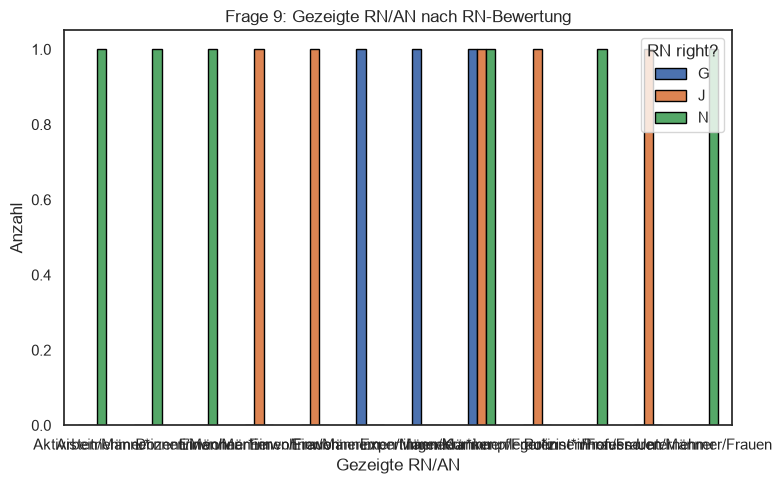

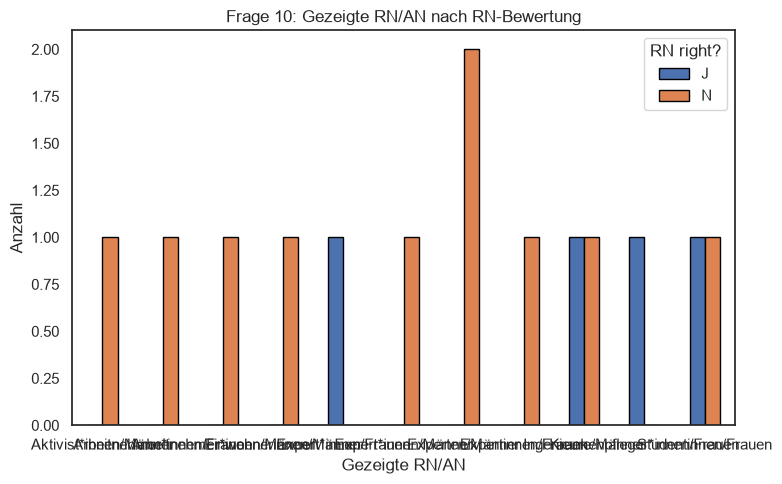

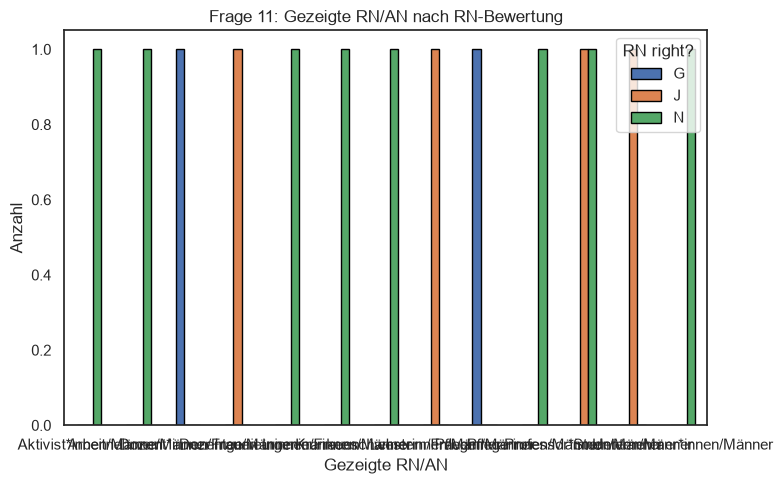

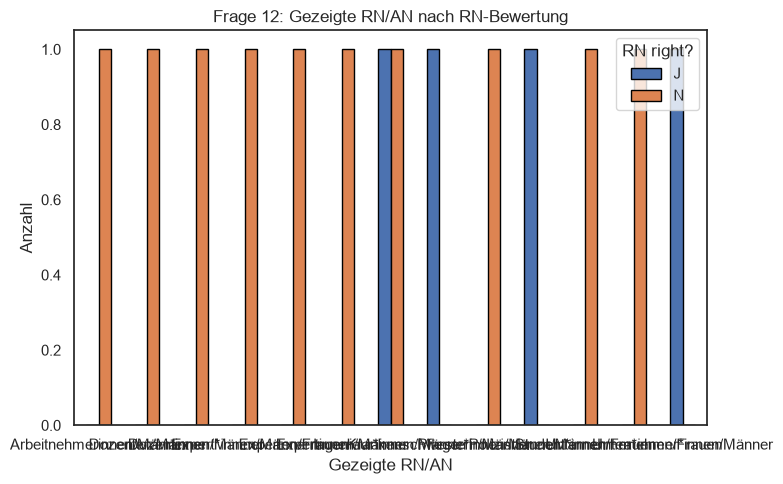

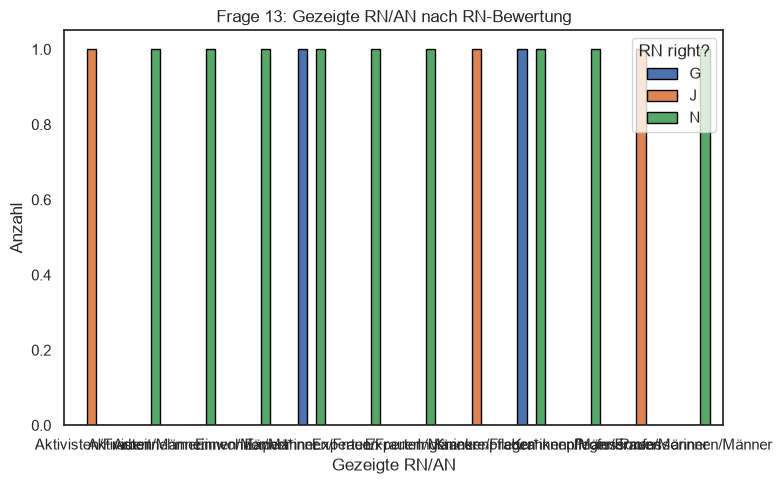

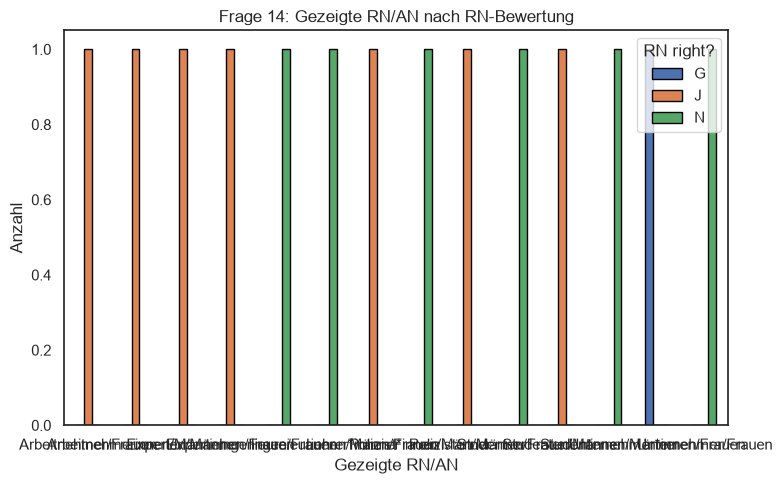

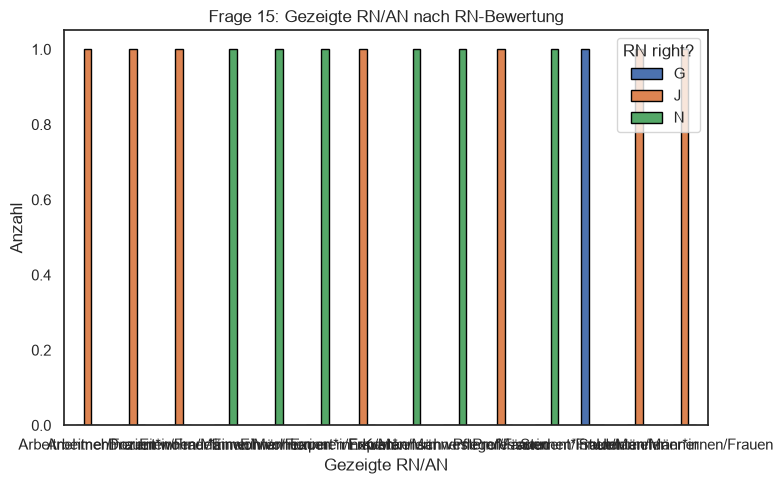

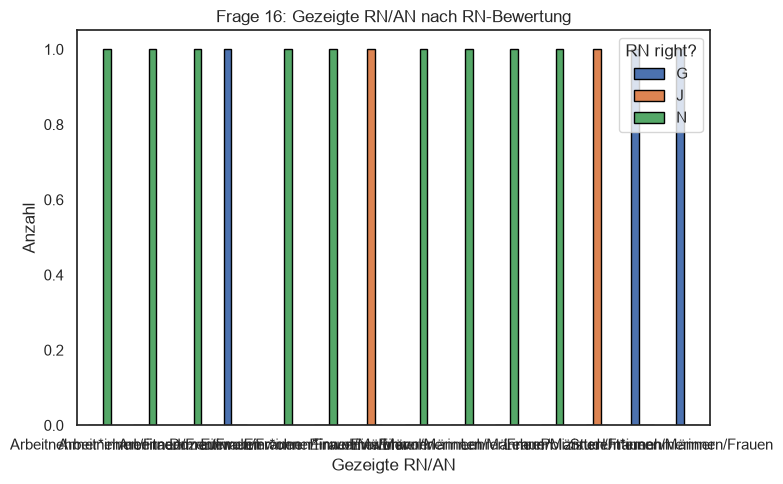

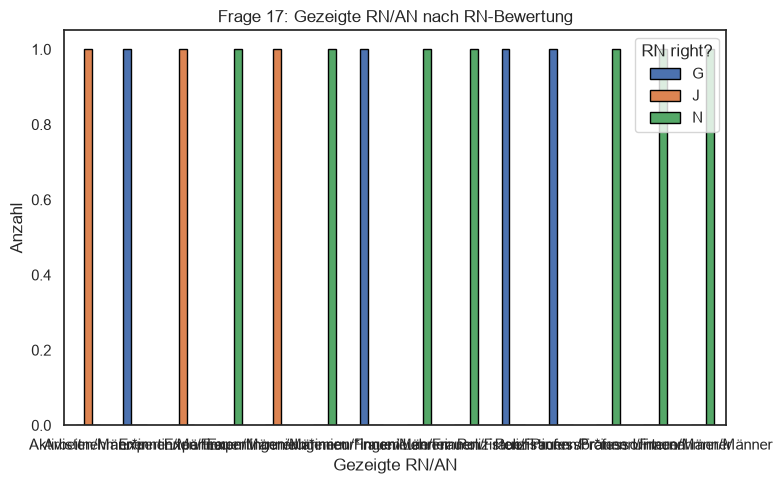

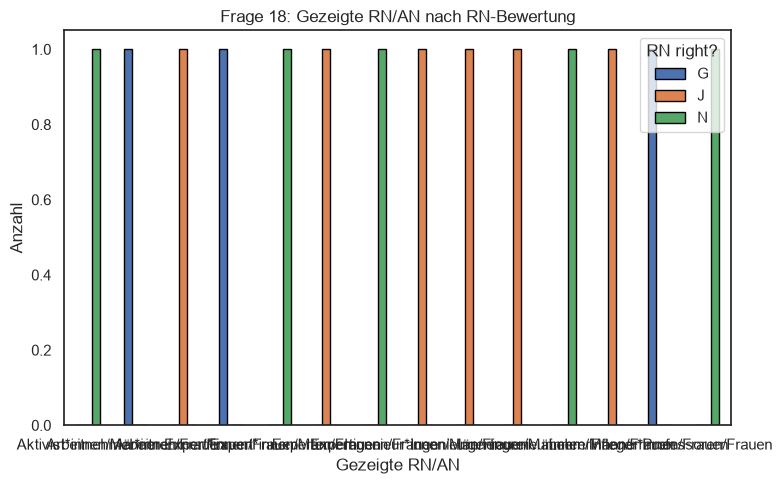

In [ ]:
for i in range(1, 19):

    gezeigt = df_during[f"{i}. gezeigte RN/AN"]
    rn = df_rnan[f"{i}. RN right?"]

    tabelle = pd.crosstab(gezeigt, rn)

    tabelle.plot(
        kind="bar",
        figsize=(8, 5),
        edgecolor="black"
    )

    plt.xlabel("Gezeigte RN/AN")
    plt.ylabel("Anzahl")
    plt.title(f"Frage {i}: Gezeigte RN/AN nach RN-Bewertung")
    plt.xticks(rotation=0)
    plt.legend(title="RN right?")
    plt.tight_layout()
    plt.show()

In [ ]:
codes = []

for i in range(1, 19):
    code = df_during[f"{i}.Code"]
    rn = df_rnan[f"{i}. RN right? "]

    codes.extend(zip(code, rn))

df_codes = pd.DataFrame(codes, columns=["Code", "RN"])

# J, N und G zählen
tabelle = pd.crosstab(df_codes["Code"], df_codes["RN"])

# Reihenfolge festlegen
tabelle = tabelle.reindex(
    ["C1", "C2", "C3", "C4", "C5", "C6"],
    fill_value=0
)

tabelle = tabelle.reindex(
    columns=["J", "N", "G"],
    fill_value=0
)

# Plot
tabelle.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.xlabel("Code")
plt.ylabel("Anzahl")
plt.title("RN-Bewertung nach gezeigtem Code")
plt.xticks(rotation=0)

plt.legend(
    ["Richtig", "Falsch", "Falsches Gender"],
    title="RN-Bewertung"
)

plt.tight_layout()
plt.show()

KeyError: '4.Code'

In [ ]:
print(df_during.columns.tolist())

['Subject', '1. Welches Thema', '1. Verwirrt?', '1. gennante RN/AN', '1. gezeigte RN/AN', '2. Welches Thema', '2. Verwirrt?', '2. gennante RN/AN', '2. gezeigte RN/AN', '3. Welches Thema', '3. Verwirrt?', '3. gennante RN/AN', '3. gezeigte RN/AN', '4. Welches Thema', '4. Verwirrt?', '4. gennante RN/AN', '4. gezeigte RN/AN', '5. Welches Thema', '5. Verwirrt?', '5. gennante RN/AN', '5. gezeigte RN/AN', '6. Welches Thema', '6. Verwirrt?', '6. gennante RN/AN', '6. gezeigte RN/AN', '7. Welches Thema', '7. Verwirrt?', '7. gennante RN/AN', '7. gezeigte RN/AN', '8. Welches Thema', '8. Verwirrt?', '8. gennante RN/AN', '8. gezeigte RN/AN', '9. Welches Thema', '9. Verwirrt?', '9. gennante RN/AN', '9. gezeigte RN/AN', '10. Welches Thema', '10. Verwirrt?', '10. gennante RN/AN', '10. gezeigte RN/AN', '11. Welches Thema', '11. Verwirrt?', '11. gennante RN/AN', '11. gezeigte RN/AN', '12. Welches Thema', '12. Verwirrt?', '12. gennante RN/AN', '12. gezeigte RN/AN', '13. Welches Thema', '13. Verwirrt?', '1